# Error Gating: does it induce a blocked preference?

In [4]:
import pandas as pd
import numpy as np
from experimental_setups import error_gating_model, isc_model
import data
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from experimental_setups.error_gating_model import *

In [3]:
from pathlib import Path

isc_path = Path('data/oja_baseline_comparison.csv')
results_path = Path('data/error_baseline_comparison.csv')
lc_path = Path('data/error_learning_curves.csv')

if lc_path.exists():
    lc_df = pd.read_csv(lc_path)
else:
    old_error_data = pd.read_csv(isc_path)
    old_error_data = old_error_data[old_error_data['architecture'] == 'ISC']
    error_data = []
    lc_data = []
    num_epochs = 40

    print('Now training error gating model...')
    hebb_errors, hebb_lc = run_error_experiment(num_epochs=num_epochs, alpha=0., track_learning_curves=True)
    error_data += hebb_errors
    lc_data += hebb_lc
    print('\t...finished!\n')

    error_data = pd.concat(error_data, axis=0, ignore_index=True)
    error_data = pd.concat([error_data, old_error_data], axis=0, ignore_index=True)
    error_data.to_csv(results_path, index=False)

    # force bce to plain Python float before concat to avoid object-dtype 0-d arrays
    for df in lc_data:
        df['bce'] = [float(v) for v in df['bce']]

    lc_df = pd.concat(lc_data, axis=0, ignore_index=True)
    lc_df.to_csv(lc_path, index=False)

lc_df['epoch'] = lc_df['epoch'].astype(int)
lc_df['bce'] = lc_df['bce'].astype(float)

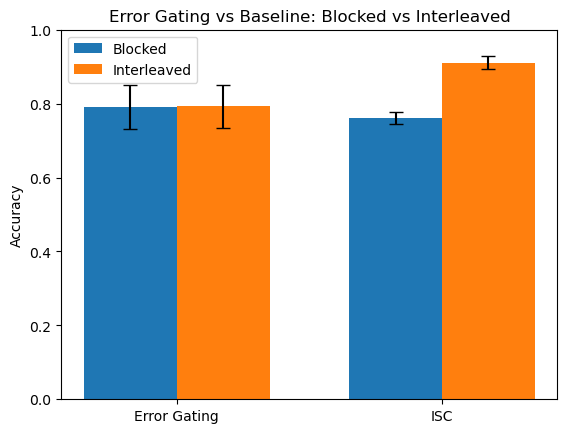

In [8]:
df = pd.read_csv('data/error_baseline_comparison.csv')

model_means = df.groupby(['architecture', 'condition', 'model'])['acc'].mean()
stats = model_means.groupby(['architecture', 'condition']).agg(['mean', 'std'])

def get_mean_std(arch, cond):
    row = stats.loc[(arch, cond)]
    return row['mean'], row['std']

hebbian_blocked_mean,     hebbian_blocked_std     = get_mean_std("Hebbian", "blocked")
hebbian_interleaved_mean, hebbian_interleaved_std = get_mean_std("Hebbian", "interleaved")
isc_blocked_mean,         isc_blocked_std         = get_mean_std("ISC", "blocked")
isc_interleaved_mean,     isc_interleaved_std     = get_mean_std("ISC", "interleaved")

models = ["Error Gating", "ISC"]
blocked         = [hebbian_blocked_mean,      isc_blocked_mean]
blocked_err     = [hebbian_blocked_std,       isc_blocked_std]
interleaved     = [hebbian_interleaved_mean,  isc_interleaved_mean]
interleaved_err = [hebbian_interleaved_std,   isc_interleaved_std]

x = np.arange(len(models))
width = 0.35

plt.figure()
plt.bar(x - width/2, blocked,     width, label="Blocked",     yerr=blocked_err,     capsize=5)
plt.bar(x + width/2, interleaved, width, label="Interleaved", yerr=interleaved_err, capsize=5)

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Error Gating vs Baseline: Blocked vs Interleaved")
plt.legend()
plt.ylim(0, 1)
plt.savefig('images/ema/error_baseline')
plt.show()